# iso codes

In [14]:
import arxiv
import re
from iso639.language import ALL_LANGUAGES
from datetime import datetime, timedelta

# Construct the default API client.
client = arxiv.Client()

# Calculate date range for last 7 days
end_date = datetime.now()
start_date = end_date - timedelta(days=7)

# Format dates for arXiv API (YYYYMMDDHHMM)
start_date_str = start_date.strftime("%Y%m%d%H%M")
end_date_str = end_date.strftime("%Y%m%d%H%M")

# Build query with category and date filter
query = f"cat:cs.CL AND submittedDate:[{start_date_str} TO {end_date_str}]"
search = arxiv.Search(query=query, max_results=50, sort_by=arxiv.SortCriterion.SubmittedDate)

results = client.results(search)
for result in results:
    abstract = result.summary
    title = result.title
    
    # 2. Hard constraint: Only look for languages explicitly mentioned in Title/Abstract
    detected_languages = []
    false_positives = {"English", "Modern", "Program", "The", "Are", "Day"}
    
    for lang in ALL_LANGUAGES:
        name = lang.name
        alpha3 = lang.part3
        if not name or not alpha3:
            continue
        # Avoid short matching like 'it' or 'no' by matching full words and require name length >=4
        if len(name) < 4:
            continue
        pattern = r"\b" + re.escape(name) + r"\b"
        if re.search(pattern, abstract, re.IGNORECASE) or re.search(pattern, title, re.IGNORECASE):
            if name not in false_positives:
                detected_languages.append(f"{name} ({alpha3})")  # Full language name with code

    # Example output
    print(f"Title: {title}")
    print(f"Detected languages: {detected_languages}")


Title: ATLAS: Agentic or Latent Visual Reasoning? One Word is Enough for Both
Detected languages: []
Title: FutureSim: Replaying World Events to Evaluate Adaptive Agents
Detected languages: []
Title: Is Grep All You Need? How Agent Harnesses Reshape Agentic Search
Detected languages: ['Even (eve)']
Title: MetaBackdoor: Exploiting Positional Encoding as a Backdoor Attack Surface in LLMs
Detected languages: ['Even (eve)']
Title: Text Knows What, Tables Know When: Clinical Timeline Reconstruction via Retrieval-Augmented Multimodal Alignment
Detected languages: []
Title: MeMo: Memory as a Model
Detected languages: []
Title: Self-Distilled Agentic Reinforcement Learning
Detected languages: []
Title: Forgetting That Sticks: Quantization-Permanent Unlearning via Circuit Attribution
Detected languages: []
Title: MemEye: A Visual-Centric Evaluation Framework for Multimodal Agent Memory
Detected languages: []
Title: Talk is (Not) Cheap: A Taxonomy and Benchmark Coverage Audit for LLM Attacks
Det

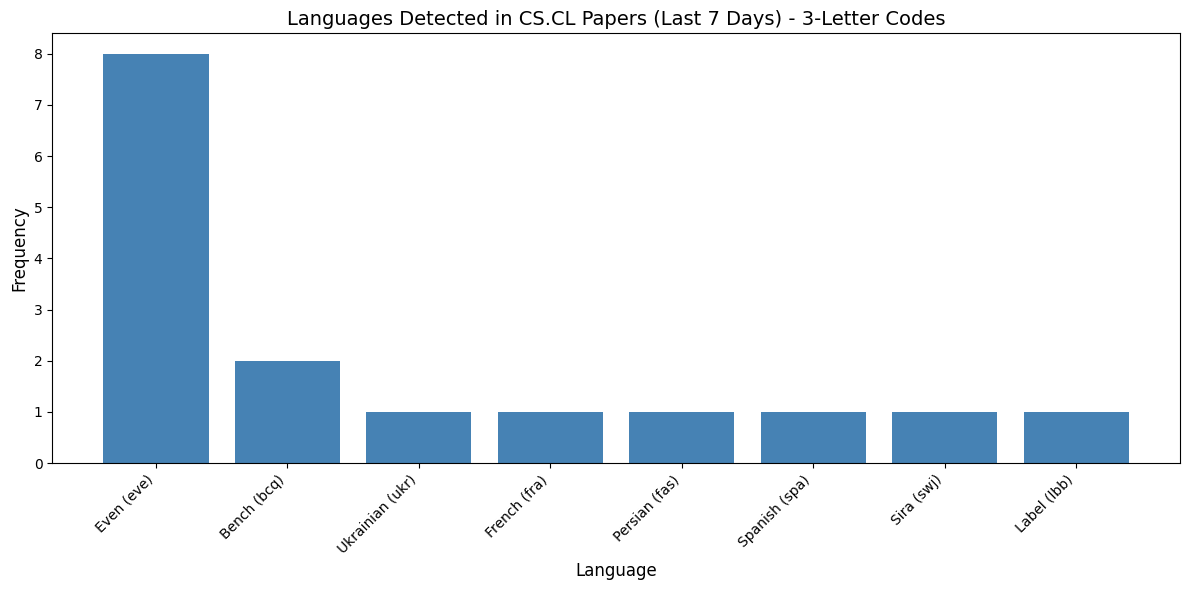

Total papers analyzed: 50
Total language mentions detected: 16
Unique languages detected: 8


In [15]:
import matplotlib.pyplot as plt
from collections import Counter
import arxiv
import re
from iso639.language import ALL_LANGUAGES
from datetime import datetime, timedelta

# Construct the default API client.
client = arxiv.Client()

# Calculate date range for last 7 days
end_date = datetime.now()
start_date = end_date - timedelta(days=7)

# Format dates for arXiv API (YYYYMMDDHHMM)
start_date_str = start_date.strftime("%Y%m%d%H%M")
end_date_str = end_date.strftime("%Y%m%d%H%M")

# Build query with category and date filter
query = f"cat:cs.CL AND submittedDate:[{start_date_str} TO {end_date_str}]"
search = arxiv.Search(query=query, max_results=50, sort_by=arxiv.SortCriterion.SubmittedDate)

# Collect all detected languages (with codes)
all_detected_languages = []
false_positives = {"English", "Modern", "Program", "The", "Are", "Day"}

results = client.results(search)
for result in results:
    abstract = result.summary
    title = result.title
    detected_languages = []
    
    for lang in ALL_LANGUAGES:
        name = lang.name
        alpha3 = lang.part3
        if not name or not alpha3:
            continue
        if len(name) < 4:
            continue
        pattern = r"\b" + re.escape(name) + r"\b"
        if re.search(pattern, abstract, re.IGNORECASE) or re.search(pattern, title, re.IGNORECASE):
            if name not in false_positives:
                detected_languages.append(f"{name} ({alpha3})")
    
    all_detected_languages.extend(detected_languages)

# Count language occurrences
language_counter = Counter(all_detected_languages)

if language_counter:
    # Get top 10 most detected languages
    top_languages = language_counter.most_common(10)
    display_names, counts = zip(*top_languages)
    
    # Create bar chart
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(display_names)), counts, color='steelblue')
    plt.xticks(range(len(display_names)), display_names, rotation=45, ha='right')
    plt.xlabel('Language', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Languages Detected in CS.CL Papers (Last 7 Days) - 3-Letter Codes', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print(f"Total papers analyzed: {len(list(client.results(search)))}")
    print(f"Total language mentions detected: {len(all_detected_languages)}")
    print(f"Unique languages detected: {len(language_counter)}")
else:
    print("No languages detected in papers from the last 7 days.")


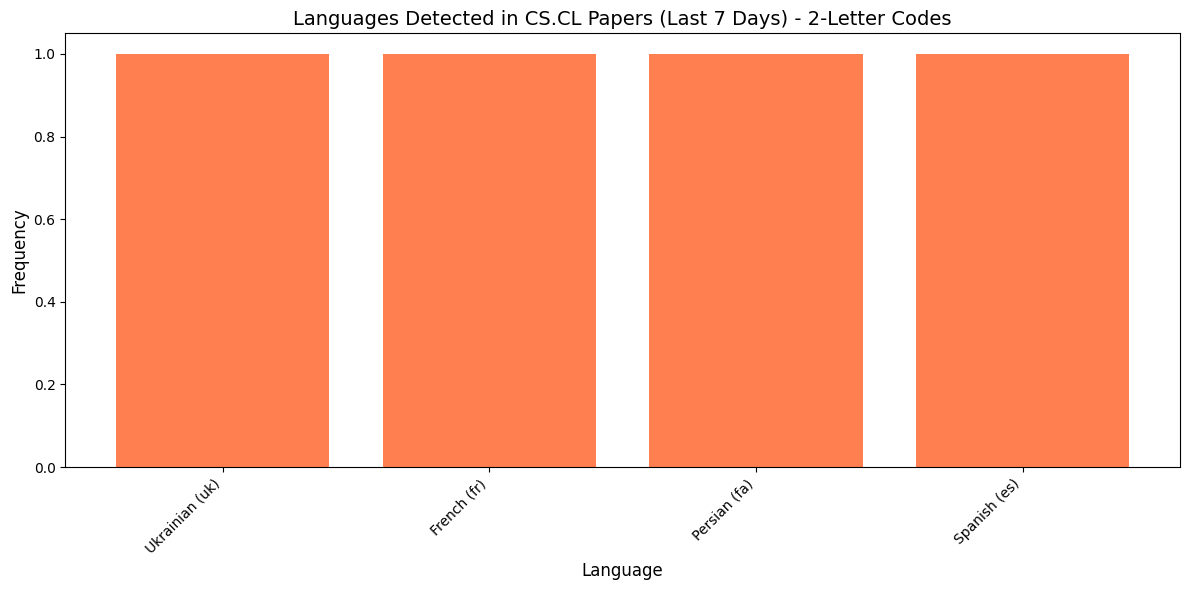

Total papers analyzed: 50
Total language mentions detected: 4
Unique languages detected: 4


In [16]:
import matplotlib.pyplot as plt
from collections import Counter
import arxiv
import re
from iso639.language import ALL_LANGUAGES
from datetime import datetime, timedelta

# Construct the default API client.
client = arxiv.Client()

# Calculate date range for last 7 days
end_date = datetime.now()
start_date = end_date - timedelta(days=7)

# Format dates for arXiv API (YYYYMMDDHHMM)
start_date_str = start_date.strftime("%Y%m%d%H%M")
end_date_str = end_date.strftime("%Y%m%d%H%M")

# Build query with category and date filter
query = f"cat:cs.CL AND submittedDate:[{start_date_str} TO {end_date_str}]"
search = arxiv.Search(query=query, max_results=50, sort_by=arxiv.SortCriterion.SubmittedDate)

# Collect all detected languages using 2-letter codes (ISO 639-1)
all_detected_languages_2letter = []
false_positives = {"English", "Modern", "Program", "The", "Are", "Day"}

results = client.results(search)
for result in results:
    abstract = result.summary
    title = result.title
    detected_languages = []
    
    for lang in ALL_LANGUAGES:
        name = lang.name
        part1 = lang.part1  # 2-letter code
        if not name or not part1:
            continue
        if len(name) < 4:
            continue
        pattern = r"\b" + re.escape(name) + r"\b"
        if re.search(pattern, abstract, re.IGNORECASE) or re.search(pattern, title, re.IGNORECASE):
            if name not in false_positives:
                detected_languages.append(f"{name} ({part1})")
    
    all_detected_languages_2letter.extend(detected_languages)

# Count language occurrences
language_counter_2letter = Counter(all_detected_languages_2letter)

if language_counter_2letter:
    # Get top 10 most detected languages
    top_languages_2letter = language_counter_2letter.most_common(10)
    display_names_2letter, counts_2letter = zip(*top_languages_2letter)
    
    # Create bar chart
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(display_names_2letter)), counts_2letter, color='coral')
    plt.xticks(range(len(display_names_2letter)), display_names_2letter, rotation=45, ha='right')
    plt.xlabel('Language', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Languages Detected in CS.CL Papers (Last 7 Days) - 2-Letter Codes', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print(f"Total papers analyzed: {len(list(client.results(search)))}")
    print(f"Total language mentions detected: {len(all_detected_languages_2letter)}")
    print(f"Unique languages detected: {len(language_counter_2letter)}")
else:
    print("No languages detected in papers from the last 7 days.")


# Pipeline (from some language code repo (lang filter))

In [7]:
import arxiv
import re
from datetime import datetime, timedelta
import time
import json, os

### language data extraction

In [ ]:
# from https://github.com/dilithjay/Shoulders-of-Giants/blob/main/categorize_filtered_papers.ipynb

def replace_non_letters_with_spaces(input_string):
    # Replace non-letter characters with spaces
    result_string = re.sub(r'[^a-zA-ZÀ-ÿ ]', ' ', input_string)
    return result_string

# Define languages to ignore 
languages_to_ignore ="Apache,Laura,Fang,Mono,Ma,Maria,Sam,Bench,Zhuang,Male,Nara,So,Hu,Kim,Label,The,To,Yong,The,To,Adele,Are,Foma,Kaur,Bau,Kato,Dek,Naman,Dom,As,The,To,As,Dan,E,The,To,U,Even,En,Chung,Dong,Shi,Tai,Thompson,Gao,Ir,Pan,Ali,Rao,Han,Doe,Titan,Ha,Sa,Tu,Lau,Siri,Wan,She,Dai,Ding,Kang,Ge,Koch,Che,Mann,Zou,Pei,Yao,Lou,Sydney,Ju,Sha,Day,Miwa,Bai,Ko,Ga,Pal,Pe,Gun,Hung,Con,Cun,Serrano,Sui,Bu,Mehri,Od,Haji,Gal,Gey,Lui,Ho,Furu,Ak,Kao,Aro,Gen,Moro,Notre,Ido,Ron,Were,Bai,Sahu,Dem,Melo,Rama,Hunde,Dii,Yala,Sauri".split(',')
languages_to_ignore=languages_to_ignore+"Uni,One,Yi,Na,Bit,Pa".split(',') + ["are", "as", "e", "en", "even", "one", "so", "to", "apache", "au", "u", "bit", "she", "siri", "day", "gun", "label", "notre"]
languages_to_ignore = set(languages_to_ignore)

# Load lang_classes from categorize_filtered_papers.ipynb
lang_classes = {}
base_path = "../Some-Languages-are-More-Equal-than-Others/Language_List/Language_Classes_According_To/DataSet_Availability"

for i in range(6):
    file_path = f"{base_path}/{i}.txt"
    try:
        with open(file_path, "r", encoding="utf-8") as fp:
            lang_classes[i] = set(fp.read().strip().split("\n"))
            print(f"✓ Loaded class {i}: {len(lang_classes[i])} languages")
    except FileNotFoundError:
        print(f"✗ Could not find file for class {i}: {file_path}")

print(f"Total unique languages across all classes: {len(set.union(*lang_classes.values()))}")
print(f"Total languages to ignore: {len(languages_to_ignore)}")
# print(f"lang classes: {lang_classes}")

# save lang_classes and languages_to_ignore for later use
output_data = {
    "lang_classes": {str(k): list(v) for k, v in lang_classes.items()},
    "languages_to_ignore": list(languages_to_ignore)
}   
print(f"Output data sample: {json.dumps(output_data, ensure_ascii=False, indent=4)[:500]}...")
output_file = "../data/processed/language_data.json"
with open(output_file, "w", encoding="utf-8") as fp:
    json.dump(output_data, fp, ensure_ascii=False, indent=4)
print(f"Saved language data to {output_file}")

### extract arxiv papers metadata (abstract, title, authors, categories, published date, etc.) using arxiv api

In [26]:
# Construct the default API client with delay
client = arxiv.Client()

In [8]:
# Calculate date range for last time_window days
# end_date = datetime.now()
# technically this should be Monday
end_date = datetime.now() - timedelta(days=datetime.now().weekday())  # Get last Monday
print(f"✓ Using end date: {end_date.strftime('%Y-%m-%d')} (last Monday)")

# set the time for 00:0000 to avoid timezone issues
end_date = end_date.replace(hour=0, minute=0, second=0, microsecond=0)
time_window = 7 # week
# time_window = 30 # month
max_results = 1000 # cap for performance

start_date = end_date - timedelta(days=time_window)

# Format dates for arXiv API (YYYYMMDDHHMM)
start_date_str = start_date.strftime("%Y%m%d%H%M")
end_date_str = end_date.strftime("%Y%m%d%H%M")
print(f"✓ Using start date: {start_date.strftime('%Y%m%d%H%M')} (end date - {time_window} days)")
print(f"✓ Using end date: {end_date.strftime('%Y%m%d%H%M')} (last Monday)")

✓ Using end date: 2026-05-25 (last Monday)
✓ Using start date: 202605180000 (end date - 7 days)
✓ Using end date: 202605250000 (last Monday)


In [ ]:
# Build query with category and date filter
# query = f"cat:cs.CL"
query = f"cat:cs.CL AND submittedDate:[{start_date_str} TO {end_date_str}]"
search = arxiv.Search(query=query, max_results=max_results, sort_by=arxiv.SortCriterion.SubmittedDate)
try:
    results = client.results(search)
    # save results to a list to avoid multiple API calls
    results_list = list(results)
    print(f"✓ Successfully retrieved {len(results_list)} papers from arXiv")
    max_results_reached = True
    # test if the max_results limit is hit
    if len(results_list) < max_results:
        max_results_reached = False
        print(f"✓ Max results limit of {max_results} not reached, retrieved all available papers in the time window.")
    else:
        print(f"✓ Max results limit of {max_results} reached, there may be more papers in the time window.")
    # save to jsonl
    os.makedirs("../data/raw/extracted_papers_metadata", exist_ok=True)
    with open(f"../data/raw/extracted_papers_metadata/arxiv_papers_{start_date.strftime('%Y%m%d')}_to_{end_date.strftime('%Y%m%d')}.jsonl", "w", encoding="utf-8") as fp:
        for result in results_list:
            paper_data = {
                "id": result.entry_id,
                "title": result.title,
                "abstract": result.summary,
                "authors": [author.name for author in result.authors],
                "published": result.published.isoformat(),
                "updated": result.updated.isoformat(),
                "categories": result.categories,
                "pdf_url": result.pdf_url
            }
            fp.write(json.dumps(paper_data) + "\n")
except Exception as e:
    print(f"✗ Error retrieving papers from arXiv: {e}")
    results_list = []

### load extracted language data and paper data

In [9]:
# read back the saved results
try:    
    with open(f"../data/raw/extracted_papers_metadata/arxiv_papers_{start_date.strftime('%Y%m%d')}_to_{end_date.strftime('%Y%m%d')}.jsonl", "r", encoding="utf-8") as fp:
        loaded_results = [json.loads(line) for line in fp]
    print(f"✓ Successfully loaded {len(loaded_results)} papers from saved JSONL")
except Exception as e:
    print(f"✗ Error loading papers from JSONL: {e}")
paper_list = loaded_results
paper_list 

✓ Successfully loaded 359 papers from saved JSONL


[{'id': 'http://arxiv.org/abs/2605.22821v1',
  'title': 'Tokenisation via Convex Relaxations',
  'abstract': 'Tokenisation is an integral part of the current NLP pipeline. Current tokenisation algorithms such as BPE and Unigram are greedy algorithms -- they make locally optimal decisions without considering the resulting vocabulary as a whole. We instead formulate tokeniser construction as a linear program and solve it using convex optimisation tools, yielding a new algorithm we call ConvexTok. We find ConvexTok consistently improves intrinsic tokenisation metrics and the bits-per-byte (BpB) achieved by language models; it also improves downstream task performance, but less consistently. Furthermore, ConvexTok allows the user to certify how far their tokeniser is from optimal, with respect to a certain objective, via a lower bound, and we empirically find it to be within 1\\% of optimal at common vocabulary sizes.',
  'authors': ['Jan Tempus',
   'Philip Whittington',
   'Craig W. Schm

In [10]:
# read back the saved data
output_file = "../data/processed/language_data.json"
if os.path.exists(output_file):
    with open(output_file, "r", encoding="utf-8") as fp:
        loaded_data = json.load(fp)
        lang_classes = {int(k): set(v) for k, v in loaded_data["lang_classes"].items()}
        languages_to_ignore = set(loaded_data["languages_to_ignore"])
    print(f"✓ Successfully loaded language data from {output_file}")
else:
    print(f"✗ Could not find language data file: {output_file}")


✓ Successfully loaded language data from ../data/processed/language_data.json


### cleaning functions 

In [2]:
def detect_languages_in_text(text_list: list, lang_classes: dict, languages_to_ignore: list, paper_id: str | None = None) -> list:
    language_occurrences = []
    if isinstance(lang_classes, dict):
        language_groups = lang_classes.values()
    else:
        language_groups = lang_classes

    for text in text_list:
        if not isinstance(text, str):
            continue
        for langs in language_groups:
            if isinstance(langs, str):
                candidate_languages = [langs]
            else:
                try:
                    candidate_languages = list(langs)
                except TypeError:
                    candidate_languages = [langs]
            for lang in candidate_languages:
                if not isinstance(lang, str):
                    continue
                if lang in languages_to_ignore:
                    continue
                if "should_ignore_acronym_language_match" in globals() and should_ignore_acronym_language_match(text, lang, paper_id=paper_id):
                    continue
                if _matches_language_name(text, lang):
                    language_occurrences.append(lang)
    return language_occurrences

In [3]:
import re
import unicodedata
from collections import Counter

def _normalize_text_for_screening(text: str) -> str:
    # Keep this language-agnostic: normalize unicode and reduce whitespace only.
    normalized = unicodedata.normalize("NFKC", text).replace(" ", " ")
    normalized = normalized.replace("et al .", "et al.")
    return normalized

_APOSTROPHE_VARIANTS = "'’ʼʻʹʽ`"
_HYPHEN_VARIANTS = "-‐‑‒–—−"
# Punctuation/symbols observed in language names and requested to preserve.
_LANGUAGE_NAME_EXTRA_CHARS = "()|!‡"


def _collect_allowed_language_chars() -> set[str]:
    allowed = set(_APOSTROPHE_VARIANTS + _HYPHEN_VARIANTS + _LANGUAGE_NAME_EXTRA_CHARS)

    # Prefer the language inventory from earlier cells.
    if "lang_classes" in globals() and isinstance(lang_classes, dict):
        for langs in lang_classes.values():
            for lang in langs:
                if lang:
                    allowed.update(unicodedata.normalize("NFKC", lang))

    # Fallback to precomputed unique characters if available.
    if "unique_characters" in globals() and isinstance(unique_characters, set):
        allowed.update(unique_characters)

    return allowed


_ALLOWED_LANGUAGE_CHARS = _collect_allowed_language_chars()


def _should_keep_language_char(ch: str) -> bool:
    if ch.isspace():
        return True
    return ch in _ALLOWED_LANGUAGE_CHARS


def replace_non_letters_with_spaces(input_string):
    """Replace characters that are not language-name characters or whitespace with spaces."""
    out_chars = []
    for ch in input_string:
        if _should_keep_language_char(ch):
            out_chars.append(ch)
        else:
            out_chars.append(" ")
    return "".join(out_chars)


# Inline author-year citations where "et al." appears OUTSIDE parens:
# e.g. "Cemri et al. ( 2026 )", "Smith et al. (2024a)"
_CITATION_AUTHOR_YEAR_RE = re.compile(
    r"\b\w+\s+et\s+al\.?\s*\(\s*(?:19|20)\d{2}[a-z]?\s*\)",
    re.IGNORECASE,
)
# Parenthetical citations such as (Li et al., 2024), (Zouhar et al 2023a), etc.
_CITATION_PAREN_RE = re.compile(
    r"\((?=[^()]{0,260}\b(?:et\s+al\.?|(?:19|20)\d{2}[a-z]?)\b)[^()]{0,300}\)",
    re.IGNORECASE,
)
# Inline math / display math markers
_INLINE_MATH_RE = re.compile(r"\$[^$]+\$|\\\([^)]*\\\)|\\\[[^\]]*\\\]")
# Common LaTeX math commands and fragments, including colour blocks such as {\color...}
_MATH_COMMAND_RE = re.compile(
    r"\\(?:math[a-zA-Z]+|frac|left|right|mathrm|mathbf|mathsf|mathtt|begin|end|color|definecolor)\b(?:\{[^{}]*\})?",
    re.IGNORECASE,
)
_COLOR_BLOCK_RE = re.compile(r"\{\\color[^{}]*\}|\\color\[[^\]]*\]\{[^{}]*\}|\\definecolor\[[^\]]*\]\{[^{}]*\}", re.IGNORECASE)
# Standalone numbers such as years or equation indices when they appear as their own token
_STANDALONE_NUMBER_RE = re.compile(r"(?<!\w)\d+(?:\.\d+)?(?!\w)")
# Alphanumeric token fragments like 256k, k128, 3b, etc.
_ALNUM_TOKEN_RE = re.compile(r"(?<!\w)(?:\d+[a-zA-Z]+|[a-zA-Z]+\d+)(?!\w)")
# Common LaTeX residue tokens that often survive command stripping
_LATEX_ARTIFACT_TOKEN_RE = re.compile(r"\b(?:rgb|named|definecolor|pgfstrokecolor|color)\b", re.IGNORECASE)

# Code/pseudocode residue: must run BEFORE _INLINE_MATH_RE so bracket context is still present.
#
# _DEF_FUNCTION_BLOCK_RE: whole def...return block (single-block case)
_DEF_FUNCTION_BLOCK_RE = re.compile(
    r"\bdef\s+[A-Za-z_]\w*\s*\([^\)]*\)\s*:.*?\breturn\b.*?(?=\bdef\s+[A-Za-z_]\w*\s*\([^\)]*\)\s*:|$)",
    re.IGNORECASE | re.DOTALL,
)
# col = <any rhs on the same line>, with optional @/$/\ prefix (e.g. col = sort(...), col = value)
_COL_ASSIGNMENT_RE = re.compile(r"\bcol(?:[@$\\])?\s*=\s*[^\n]+", re.IGNORECASE)
# col followed by @/$ math markers then an index/slice bracket (e.g. col@$ [0:n] $@)
_COL_SLICE_RE = re.compile(r"\bcol(?:[@$\\])?\s*\[[^\]]+\]", re.IGNORECASE)
# col@ / col@$ remnant left after inline-math stripping removes the bracket content
_COL_MATH_MARKER_RE = re.compile(r"\bcol[@$\\]+", re.IGNORECASE)


# Collapse extra whitespace introduced by cleaning
_MULTI_SPACE_RE = re.compile(r"\s+")


def _language_regex(language_name: str) -> str:
    parts = []
    for character in language_name:
        if character in _APOSTROPHE_VARIANTS:
            parts.append(r"['’ʼʻʹʽ`]")
        elif character in _HYPHEN_VARIANTS:
            parts.append(r"[-‐‑‒–—−]")
        else:
            parts.append(re.escape(character))
    return r"(?<!\w)" + "".join(parts) + r"(?!\w)"


def _matches_language_name(text: str, language_name: str) -> bool:
    return re.search(_language_regex(language_name), text, re.IGNORECASE) is not None


def clean_paper_text_for_language_screening(text: str) -> tuple[list[str], dict]:
    """Return (cleaned_blocks, step_matches) for language screening."""
    if not text:
        return [], {}

    normalized = _normalize_text_for_screening(text)
    cleaned_blocks: list[str] = []
    step_matches: dict = {}

    # Split only on paragraph-like boundaries, not by sentence.
    for block in re.split(r"\n{2,}|\r\n{2,}", normalized):
        block = block.strip()
        if not block:
            continue

        step_matches = {}

        # --- Code/pseudocode cleanup (before inline-math stripping so bracket context survives) ---
        matches = _DEF_FUNCTION_BLOCK_RE.findall(block)
        if matches:
            step_matches['def_return_funcs'] = matches[:5]
        block = _DEF_FUNCTION_BLOCK_RE.sub(
            lambda m: _COL_MATH_MARKER_RE.sub(" ", _COL_SLICE_RE.sub(" ", _COL_ASSIGNMENT_RE.sub(" ", m.group(0)))),
            block,
        )
        matches = _COL_ASSIGNMENT_RE.findall(block)
        if matches:
            step_matches['col_assignment'] = matches
        block = _COL_ASSIGNMENT_RE.sub(" ", block)

        matches = _COL_SLICE_RE.findall(block)
        if matches:
            step_matches['col_slice'] = matches
        block = _COL_SLICE_RE.sub(" ", block)

        matches = _COL_MATH_MARKER_RE.findall(block)
        if matches:
            step_matches['col_math_marker'] = matches
        block = _COL_MATH_MARKER_RE.sub(" ", block)

        # --- LaTeX / HTML artifact cleanup ---
        matches = _COLOR_BLOCK_RE.findall(block)
        if matches:
            step_matches['color_blocks'] = matches
        block = _COLOR_BLOCK_RE.sub(" ", block)

        matches = _INLINE_MATH_RE.findall(block)
        if matches:
            step_matches['inline_math'] = matches
        block = _INLINE_MATH_RE.sub(" ", block)

        matches = _MATH_COMMAND_RE.findall(block)
        if matches:
            step_matches['math_commands'] = matches[:10]
        block = _MATH_COMMAND_RE.sub(" ", block)

        # Strip full inline "Name et al. (year)" citations before the paren-only pass
        matches = _CITATION_AUTHOR_YEAR_RE.findall(block)
        if matches:
            step_matches['citation_author_year'] = matches
        block = _CITATION_AUTHOR_YEAR_RE.sub(" ", block)

        matches = _CITATION_PAREN_RE.findall(block)
        if matches:
            step_matches['citation_parens'] = matches
        block = _CITATION_PAREN_RE.sub(" ", block)

        matches = _ALNUM_TOKEN_RE.findall(block)
        if matches:
            step_matches['alnum_tokens'] = matches
        block = _ALNUM_TOKEN_RE.sub(" ", block)

        matches = _STANDALONE_NUMBER_RE.findall(block)
        if matches:
            step_matches['standalone_numbers'] = matches[:20]
        block = _STANDALONE_NUMBER_RE.sub(" ", block)

        matches = _LATEX_ARTIFACT_TOKEN_RE.findall(block)
        if matches:
            step_matches['latex_artifacts'] = matches
        block = _LATEX_ARTIFACT_TOKEN_RE.sub(" ", block)

        # Replace unwanted characters while preserving only language-name characters.
        out_chars = []
        replaced = []
        for ch in block:
            if _should_keep_language_char(ch):
                out_chars.append(ch)
            else:
                out_chars.append(" ")
                replaced.append(ch)
        block = "".join(out_chars)
        if replaced:
            step_matches['replaced_chars'] = Counter(replaced)

        block = _MULTI_SPACE_RE.sub(" ", block).strip()

        if not block:
            continue

        # print(f"Cleaned block: {block}")
        # print(f"Step matches: {'\n'.join(f'{k}: {v}' for k, v in step_matches.items() if v)}")
        cleaned_blocks.append(block)

    return cleaned_blocks, step_matches

#### sample test

In [12]:
# test the language detection function on a sample abstract
# print(len(cleaned_text))
# print(cleaned_text[0])
text="""
Cemri et al. ( 2026 ); Zhu et al. ( 2026 ); Deshpande et al. ( 2025 ); Lù et al. ( 2025 )
"""
cleaned_text = [text]
for block in cleaned_text:
    print(f"Testing block: {block}")
    detected_languages, step_matches = clean_paper_text_for_language_screening(block)
    print(f"Detected languages: {detected_languages}")
    print(f"Step matches: {'\n'.join(f'{k}: {v}' for k, v in step_matches.items() if v)}")


Testing block: 
Cemri et al. ( 2026 ); Zhu et al. ( 2026 ); Deshpande et al. ( 2025 ); Lù et al. ( 2025 )

Detected languages: []
Step matches: citation_author_year: ['Cemri et al. ( 2026 )', 'Zhu et al. ( 2026 )', 'Deshpande et al. ( 2025 )', 'Lù et al. ( 2025 )']
replaced_chars: Counter({';': 3})


In [4]:
# test the abstract
for paper in paper_list:
    abstract = paper["abstract"]
    title = paper["title"]
    cleaned_blocks, step_matches = clean_paper_text_for_language_screening(abstract)
    detected_languages = detect_languages_in_text(cleaned_blocks, lang_classes, languages_to_ignore, paper_id=paper.get('id'))
    if detected_languages:
        print(f"###############")
        print(f"Testing paper: {title}")
        
        print(f"Detected languages in abstract: {detected_languages}")
        print(f"Cleaned block: {cleaned_blocks}")
        print(f"Step matches: {'\n'.join(f'{k}: {v}' for k, v in step_matches.items() if v)}")  # Only print steps that had matches
        print(f"###############")
        

✓ Successfully loaded 359 papers from saved JSONL


[{'id': 'http://arxiv.org/abs/2605.22821v1',
  'title': 'Tokenisation via Convex Relaxations',
  'abstract': 'Tokenisation is an integral part of the current NLP pipeline. Current tokenisation algorithms such as BPE and Unigram are greedy algorithms -- they make locally optimal decisions without considering the resulting vocabulary as a whole. We instead formulate tokeniser construction as a linear program and solve it using convex optimisation tools, yielding a new algorithm we call ConvexTok. We find ConvexTok consistently improves intrinsic tokenisation metrics and the bits-per-byte (BpB) achieved by language models; it also improves downstream task performance, but less consistently. Furthermore, ConvexTok allows the user to certify how far their tokeniser is from optimal, with respect to a certain objective, via a lower bound, and we empirically find it to be within 1\\% of optimal at common vocabulary sizes.',
  'authors': ['Jan Tempus',
   'Philip Whittington',
   'Craig W. Schm

### html extraction functions

In [8]:
# Attempt to fetch an HTML version of the arXiv paper, extract sections and re-check languages per-section
import requests
from bs4 import BeautifulSoup
import re
from pathlib import Path
import json


def fetch_arxiv_html(abs_url: str, timeout: int = 30):
    if not abs_url:
        print('fetch_arxiv_html: no URL provided')
        return None, None
    html_url = abs_url.replace('/abs/', '/html/')
    print(f'fetch_arxiv_html: attempting {html_url}')
    try:
        resp = requests.get(html_url, timeout=timeout)
        resp.raise_for_status()
        print(f'fetch_arxiv_html: success status={resp.status_code} content-length={len(resp.text)}')
        return resp.text, html_url
    except Exception as e:
        print(f'fetch_arxiv_html: failed to fetch {html_url}: {e}')
        return None, html_url


def _remove_section_by_heading(soup: BeautifulSoup, heading_texts: list=[]):
    # Remove by explicit header tags (h1..h6)
    removed = 0
    for h in soup.find_all(re.compile('^h[1-6]$')):
        text = h.get_text().strip().lower()
        if len(heading_texts) > 0:
            for target in heading_texts:
                if text.startswith(target.lower()):
                    print(f"_remove_section_by_heading: found heading '{h.get_text().strip()}' - removing until next heading")
                    nxt = h.next_sibling
                    try:
                        h.decompose()
                        removed += 1
                    except Exception as e:
                        print('  warning: could not decompose heading:', e)
                    while nxt:
                        cur = nxt
                        nxt = nxt.next_sibling
                        if getattr(cur, 'name', None) and re.match('^h[1-6]$', cur.name or ''):
                            print('  _remove_section_by_heading: reached next heading, stop')
                            break
                        try:
                            cur.decompose()
                            removed += 1
                        except Exception:
                            pass
                    break

    # Also remove whole <section> elements when their title/header matches
    sec_removed = 0
    for sec in soup.find_all('section'):
        h = sec.find(re.compile('^h[1-6]$'))
        if h:
            title = h.get_text().strip().lower()
            for target in heading_texts:
                if title.startswith(target.lower()):
                    try:
                        print(f"_remove_section_by_heading: removing entire <section> with title '{h.get_text().strip()}'")
                        sec.decompose()
                        sec_removed += 1
                    except Exception as e:
                        print('  warning: could not decompose section:', e)
                    break
    if removed or sec_removed:
        print(f"_remove_section_by_heading: removed {removed} nodes + {sec_removed} sections")


def clean_html_soup(html: str, remove_headings: list = None) -> BeautifulSoup:
    soup = BeautifulSoup(html, 'html.parser')

    orig_len = len(html)
    print(f'clean_html_soup: original length {orig_len}')

    # Remove obvious abstract containers
    for sel in [('blockquote', 'abstract'), ('div', 'abstract'), ('div', 'abstract-full')]:
        tag = soup.find(sel[0], class_=sel[1]) if sel[1] else None
        if tag:
            try:
                print(f"clean_html_soup: found abstract-like container <{sel[0]} class={sel[1]}> - removing")
                tag.decompose()
            except Exception as e:
                print('  warning: could not remove abstract container:', e)

    _remove_section_by_heading(soup, remove_headings)

    # Remove scripts/styles/nav/footer
    removed_misc = 0
    for tagname in ['script', 'style', 'nav', 'footer', 'header', 'aside']:
        for tag in soup.find_all(tagname):
            try:
                tag.decompose()
                removed_misc += 1
            except Exception:
                pass
    if removed_misc:
        print(f'clean_html_soup: removed {removed_misc} script/style/nav/header/footer tags')

    return soup


def extract_sections_from_soup(soup: BeautifulSoup) -> dict:
    sections = {}
    # Prefer explicit <section> blocks
    for sec in soup.find_all('section'):
        h = sec.find(re.compile('^h[1-6]$'))
        if h:
            title = h.get_text(strip=True)
        else:
            title = sec.get('id') or 'section'
        # collect paragraph-like elements within section
        paras = []
        for p in sec.find_all(['p', 'div']):
            txt = p.get_text(separator=' ', strip=True)
            if not txt:
                continue
            # skip headings captured as divs
            if re.match(r'^[A-Z][\w\s\-:,]{0,100}$', txt) and len(txt.split()) < 6 and txt.endswith(':'):
                continue
            paras.append(txt)
        if not paras:
            paras = [sec.get_text(separator=' ', strip=True)]
        sections[title] = '\n\n'.join(paras).strip()

    # If no section tags, try to split by headings (h1..h6) in body
    if not sections:
        current_title = 'body'
        current_texts = []
        for node in soup.find_all(['h1','h2','h3','h4','h5','h6','p','div']):
            if node.name and re.match('^h[1-6]$', node.name):
                if current_texts:
                    sections[current_title] = '\n\n'.join(current_texts).strip()
                current_title = node.get_text(strip=True)
                current_texts = []
            else:
                txt = node.get_text(separator=' ', strip=True)
                if txt:
                    current_texts.append(txt)
        if current_texts:
            sections[current_title] = '\n\n'.join(current_texts).strip()

    # Fallback: single body
    if not sections:
        body = soup.get_text('\n')
        sections['body'] = re.sub(r'\n{2,}', '\n\n', body).strip()

    print(f'extract_sections_from_soup: extracted {len(sections)} sections')
    # debug: print section titles (first 10)
    print('  section titles:', list(sections.keys())[:10])
    print('  sample section text representation repr():', repr(list(sections.values())[0][:200]) if sections else 'N/A')
    return sections


def recheck_languages_from_html(paper_record: dict, lang_classes: dict, languages_to_ignore: set) -> dict:
    id_url = paper_record.get('id') or paper_record.get('pdf_url') or paper_record.get('url')
    if not id_url:
        print('recheck_languages_from_html: no id/url found in paper_record')
        return {}

    html, html_url = fetch_arxiv_html(id_url)
    if not html:
        print(f'recheck_languages_from_html: no HTML available for {id_url} (tried {html_url})')
        return {}

    # Remove sections by heading titles (covers <h*> and entire <section> blocks)
    remove_headings = ['Abstract', 'References', 'Related work', 'Related Work', 'Related Works', 'Literature Review', 'Acknowledgements', 'Funding', 'Ethics', 'Ethics Statement']

    soup = clean_html_soup(html, remove_headings)

    # extract sections
    sections = extract_sections_from_soup(soup)

    paper_id = id_url

    # Prepare detections per section
    detections_per_section = {title: [] for title in sections}
    cleaned_texts_per_section = {}

    for title, text in sections.items():
        if re.search('|'.join(re.escape(heading) for heading in remove_headings), title, re.IGNORECASE):
            print(f"recheck_languages_from_html: skipping section '{title}' from language scan")
            continue

        cleaned_blocks, _ = clean_paper_text_for_language_screening(text)
        cleaned_texts_per_section[title] = '\n\n'.join(cleaned_blocks)
        if not cleaned_blocks:
            continue

        detected = detect_languages_in_text([title] + cleaned_blocks, lang_classes, languages_to_ignore, paper_id=paper_id)
        if detected:
            print(f"recheck_languages_from_html: detected languages in section '{title}': {detected}")
            detections_per_section[title] = detected

    # Save JSON with sections and per-section detections
    out_dir = Path('../data/processed/html_sections')
    out_dir.mkdir(parents=True, exist_ok=True)
    safe_name = (paper_record.get('id') or paper_record.get('pdf_url') or '').split('/')[-1]
    if not safe_name:
        safe_name = paper_record.get('title', 'paper').replace(' ', '_')[:60]
    json_path = out_dir / f"{safe_name}.json"

    sections_with_detections = {}
    for title, text in sections.items():
        sections_with_detections[title] = {
            'text': text,
            'cleaned_text': cleaned_texts_per_section.get(title, ''),
            'detected': detections_per_section.get(title, [])
        }

    try:
        with open(json_path, 'w', encoding='utf-8') as fh:
            json.dump(sections_with_detections, fh, ensure_ascii=False, indent=2)
        print(f'recheck_languages_from_html: saved sections+detections JSON to {json_path}')
    except Exception as e:
        print('recheck_languages_from_html: failed to save sections JSON:', e)

    # Summary
    total_sections_with_matches = sum(1 for v in detections_per_section.values() if v)
    total_matches = sum(len(v) for v in detections_per_section.values())
    print(f"recheck_languages_from_html: {total_sections_with_matches} sections with matches, {total_matches} total matches")

    return detections_per_section



### html pipeline full

In [5]:
import json
import re
import time
from collections import Counter
from datetime import datetime
from pathlib import Path
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed


def load_and_inspect_results(jsonl_path: str = "../data/processed/papers_with_detected_languages.jsonl"):
    """Load results JSONL and show a compact summary."""
    results = []
    papers_with_detections = 0
    total_detections = 0
    section_counts = Counter()
    language_counts = Counter()

    try:
        with open(jsonl_path, "r", encoding="utf-8") as fp:
            for line in fp:
                try:
                    record = json.loads(line)
                except json.JSONDecodeError:
                    continue

                results.append(record)
                sections = record.get("sections", {})
                if not sections:
                    continue

                papers_with_detections += 1
                for section_name, section_data in sections.items():
                    detected = section_data.get("detected_languages", [])
                    if not detected:
                        continue
                    section_counts[section_name] += 1
                    total_detections += len(detected)
                    for lang_obj in detected:
                        language_counts[lang_obj.get("language", "Unknown")] += 1

        print(f"✓ Loaded {len(results)} papers from {jsonl_path}")
        print("\n=== RESULTS SUMMARY ===")
        print(f"Papers with detections: {papers_with_detections}")
        print(f"Total language detections: {total_detections}")
        print(f"Unique section types: {len(section_counts)}")
        print("Top sections:")
        for section_name, count in section_counts.most_common(10):
            print(f"  {section_name}: {count}")
        print("Top languages:")
        for language, count in language_counts.most_common(15):
            print(f"  {language}: {count}")
        return results
    except FileNotFoundError:
        print(f"✗ Could not find {jsonl_path}")
        return []


def _process_single_paper(paper: dict, lang_classes: dict, languages_to_ignore: set) -> dict | None:
    """Process a single paper (worker function for parallel execution)."""
    paper_id = paper.get("id", "unknown")
    record = {"paper_id": paper_id, "paper": paper, "sections": {}}
    paper_has_detections = False

    try:
        abstract = paper.get("abstract", "")
        if abstract:
            cleaned_blocks, _ = clean_paper_text_for_language_screening(abstract)
            abstract_languages = detect_languages_in_text(
                cleaned_blocks, lang_classes, languages_to_ignore, paper_id=paper_id
            )
            abstract_detections = []
            for language in abstract_languages:
                for class_id, langs in lang_classes.items():
                    if language in langs:
                        abstract_detections.append({"language": language, "class": class_id})
                        break
            if abstract_detections:
                record["sections"]["abstract"] = {
                    "detected_languages": abstract_detections,
                    "warnings": [],
                }
                paper_has_detections = True

        if "recheck_languages_from_html" in globals():
            html_section_matches = recheck_languages_from_html(paper, lang_classes, languages_to_ignore)
        else:
            html_section_matches = {}

        for section_title, languages in html_section_matches.items():
            if not languages:
                continue
            section_detections = []
            for language in languages:
                for class_id, langs in lang_classes.items():
                    if language in langs:
                        section_detections.append({"language": language, "class": class_id})
                        break
            if section_detections:
                record["sections"][section_title] = {
                    "detected_languages": section_detections,
                    "warnings": [],
                }
                paper_has_detections = True

        if paper_has_detections:
            return record
        return None

    except Exception as exc:
        return {"paper_id": paper_id, "error": str(exc), "timestamp": datetime.now().isoformat()}


def process_full_paper_list_with_language_detection_parallel(
    papers: list,
    lang_classes: dict,
    languages_to_ignore: set,
    output_jsonl: str = "../data/processed/papers_with_detected_languages.jsonl",
    warnings_file: str = "../data/processed/language_detection_warnings.json",
    max_workers: int = 4,
) -> dict:
    """Process papers in parallel using ThreadPoolExecutor."""
    output_path = Path(output_jsonl)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    warnings_path = Path(warnings_file)
    all_warnings = []
    results = []
    stats = {
        "total_papers": len(papers),
        "papers_with_detections": 0,
        "total_detections": 0,
        "failed_papers": 0,
    }

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(_process_single_paper, paper, lang_classes, languages_to_ignore): idx
                   for idx, paper in enumerate(papers)}

        with tqdm(as_completed(futures), total=len(futures), desc="Processing papers") as pbar:
            for future in pbar:
                try:
                    result = future.result()
                    if result is None:
                        continue

                    if "error" in result:
                        all_warnings.append(result)
                        stats["failed_papers"] += 1
                    else:
                        results.append(result)
                        stats["papers_with_detections"] += 1
                        for section_data in result.get("sections", {}).values():
                            stats["total_detections"] += len(section_data.get("detected_languages", []))

                except Exception as exc:
                    idx = futures[future]
                    paper_id = papers[idx].get("id", "unknown")
                    all_warnings.append(
                        {"paper_id": paper_id, "error": str(exc), "timestamp": datetime.now().isoformat()}
                    )
                    stats["failed_papers"] += 1

    with open(output_path, "w", encoding="utf-8") as out_fp:
        for record in results:
            out_fp.write(json.dumps(record, ensure_ascii=False) + "\n")

    if all_warnings:
        with open(warnings_path, "w", encoding="utf-8") as wfp:
            json.dump(all_warnings, wfp, ensure_ascii=False, indent=2)
        print(f"✓ Saved {len(all_warnings)} warnings to {warnings_path}")

    print("\n=== LANGUAGE DETECTION SUMMARY ===")
    print(f"Total papers processed: {stats['total_papers']}")
    print(f"Papers with language detections: {stats['papers_with_detections']}")
    print(f"Total detections: {stats['total_detections']}")
    print(f"Failed papers: {stats['failed_papers']}")
    print(f"Output JSONL: {output_path}")
    return stats


if "paper_list" in globals() and "lang_classes" in globals() and "languages_to_ignore" in globals():
    print("Starting parallel paper list processing...")
    stats = process_full_paper_list_with_language_detection_parallel(
        paper_list,
        lang_classes,
        languages_to_ignore,
        max_workers=4,
    )
else:
    print("✗ Required variables not loaded. Run the earlier cells first.")


if Path("../data/processed/papers_with_detected_languages.jsonl").exists():
    results = load_and_inspect_results()
else:
    print("Results file not found yet. Run the processing cell first.")

In [1]:
from pathlib import Path
import json

html_sections_dir = Path("../data/processed/html_sections")
files_with_languages = []

if html_sections_dir.exists():
    json_files = sorted(html_sections_dir.glob("*.json"))
    print(f"Found {len(json_files)} JSON files in html_sections/\n")
    
    for json_file in json_files:
        with open(json_file, "r", encoding="utf-8") as f:
            data = json.load(f)
        
        for section_name, section_data in data.items():
            detected = section_data.get("detected", [])
            if detected:
                files_with_languages.append({
                    "file": json_file.name,
                    "section": section_name,
                    "languages": detected
                })
                print(f"File: {json_file.name}")
                print(f"  Section: {section_name}")
                print(f"  Languages: {detected}")
                print()
    
    print(f"\n=== SUMMARY ===")
    print(f"Total sections with detected languages: {len(files_with_languages)}")
else:
    print(f"Directory not found: {html_sections_dir}")

Found 20 JSON files in html_sections/

File: 2605.22608v1.json
  Section: Agent Meta-Evaluation
  Languages: ['Gera', 'Gera']

File: 2605.22616v1.json
  Section: 1Study 1: Sensorimotor and embodiment ratings for 3,000 Chinese lexicalized concepts
  Languages: ['Chinese', 'Chinese', 'Chinese', 'Chinese', 'Chinese', 'Chinese', 'Chinese', 'Chinese', 'Chinese', 'Chinese', 'Chinese', 'Chinese', 'Chinese', 'Italian', 'Chinese', 'English', 'Italian', 'Chinese', 'English', 'Italian', 'English', 'Italian', 'English']

File: 2605.22616v1.json
  Section: 1.1Participants
  Languages: ['Chinese', 'Chinese']

File: 2605.22616v1.json
  Section: 1.2Materials
  Languages: ['Chinese', 'Chinese']

File: 2605.22616v1.json
  Section: 1.3Procedure
  Languages: ['Chinese', 'Chinese']

File: 2605.22616v1.json
  Section: 1.4Results and discussion
  Languages: ['Chinese', 'Chinese', 'Chinese', 'Chinese', 'Italian', 'Chinese', 'English', 'Italian', 'Chinese', 'English', 'Italian', 'English', 'Italian', 'English'

# extract text from pdfs (pdf processor)

In [7]:
# test for one of the flagged papers
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
from scripts.pdf_processor import PDFProcessor
import requests

def download_pdf(pdf_url: str, output_dir: str, filename: str | None = None) -> Path:
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    if filename is None:
        filename = pdf_url.split('/')[-1].split('?')[0]
        if not filename.lower().endswith('.pdf'):
            filename = f"{filename}.pdf"

    pdf_path = output_path / filename

    response = requests.get(pdf_url, stream=True, timeout=60)
    response.raise_for_status()

    with open(pdf_path, 'wb') as file_handle:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                file_handle.write(chunk)

    return pdf_path

if flagged_papers:
    test_paper = flagged_papers[0]
    print(f"\n=== TESTING FLAGGED PAPER ===")
    print(f"Title: {test_paper['paper']['title']}")
    # print(f"Abstract: {test_paper['paper']['abstract']}")
    print(f"Detected languages: {test_paper['languages']}")
    
    url = test_paper['paper']['pdf_url']
    print(f"PDF URL: {url}")
    os.makedirs("../data/raw/pdfs", exist_ok=True)
    
    pdf_path = download_pdf(url, "../data/raw/pdfs", filename=f"{test_paper['paper']['id'].split('/')[-1]}.pdf")
    print(f"Downloaded PDF to: {pdf_path}")
    
    # Test PDF processing
    try:
        # python pdf_processor.py --input ./pdfs --output ./results this is the command to run the pdf processor, but we will just test the function directly here
        os.makedirs("../data/processed/pdf_text", exist_ok=True)
        pdf_processor = PDFProcessor(input_dir="../data/raw/pdfs", output_dir="../data/processed/pdf_text")
        stats = pdf_processor.process_directory()
        print(f"Processing stats: {stats}")
        if stats['failed'] == 0:
            print("✓ All PDFs processed successfully.")
    except Exception as e:
        print(f"✗ Error: {e}")


=== TESTING FLAGGED PAPER ===
Title: Evaluating Commercial AI Chatbots as News Intermediaries
Detected languages: [['Hindi', 3], ['Turkish', 4], ['Russian', 4], ['English', 5], ['Arabic', 5]]
PDF URL: https://arxiv.org/pdf/2605.22785v1
Downloaded PDF to: ../data/raw/pdfs/2605.22785v1.pdf

PDF Processor - Academic Research Tools

Input directory:  ../data/raw/pdfs
Output directory: ../data/processed/pdf_text

Found 1 PDF file(s)

------------------------------------------------------------

Processing: 2605.22785v1.pdf
  Extracting metadata...
  Extracting text...
  Generating markdown...
  ✓ Success! Extracted 149121 characters
    Saved to: ../data/processed/pdf_text/2605.22785v1.md

------------------------------------------------------------

📊 Processing Summary:
  Total files:     1
  ✓ Processed:     1
  ✗ Failed:        0


Processing stats: {'processed': 1, 'failed': 0, 'total': 1}
✓ All PDFs processed successfully.
